searching molecules for a smaller structure using substructure search

In [1]:
from rdkit import Chem

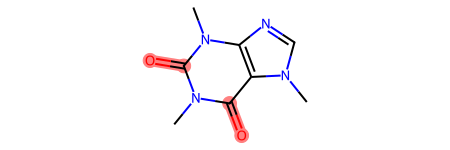

In [2]:
caffeine = Chem.MolFromSmiles('CN1C=NC2=C1C(=O)N(C(=O)N2C)C')
carbonyl = Chem.MolFromSmiles('C=O')

matches = caffeine.GetSubstructMatches(carbonyl)
caffeine


substructure search for methyl groups in caffeine

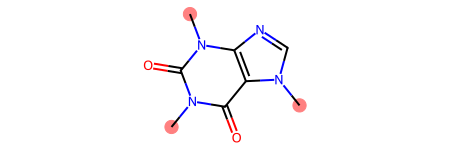

In [3]:
caffeine = Chem.MolFromSmiles('CN1C=NC2=C1C(=O)N(C(=O)N2C)C')
methyl = Chem.MolFromSmarts("[CH3]")

matches = caffeine.GetSubstructMatches(methyl)
caffeine

SMARTS (SMiles ARbitrary Target Specification) 

string is a pattern-matching language for specifying substructures in molecules. It is similar to SMILES but has additional features for specifying atom and bond properties. In contrast to SMILES, SMARTS allows for specifying substructures based on patterns of atoms and bonds, rather than just specifying the exact arrangement of atoms and bonds in a molecule.

Using a SMARTS string is necessary in this case because simply searching for a single carbon atom with the code carbon = Chem.MolFromSmiles('C') highlights all carbons in the molecule, not just the methyl group. By using a SMARTS string, we can specify the exact substructure we want to highlight and avoid highlighting unintended parts of the molecule.

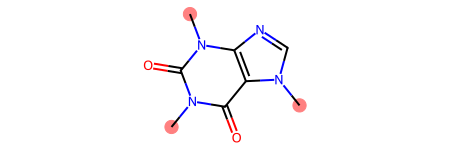

In [4]:
caffeine = Chem.MolFromSmiles("CN1C=NC2=C1C(=O)N(C(=O)N2C)C")
methyl_pattern = Chem.MolFromSmarts("[CH3]")

# Get the indices of the matching atoms
matches = caffeine.GetSubstructMatches(methyl_pattern)
caffeine

Aspirin molecule highlight any carboxyl groups in the structure. Use a SMARTS string to define the carboxyl group substructure.

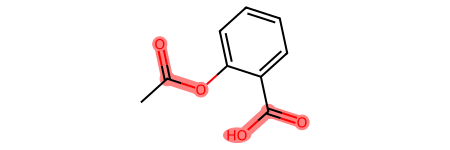

In [5]:
aspirin = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")
carboxyl = Chem.MolFromSmarts("C(=O)O")

matches = aspirin.GetSubstructMatches(carboxyl)
aspirin

Molecular Fingerprints

Molecular fingerprints are representations of molecules that are usually 
bit strings, or vectors of 0's and 1's. Fingerprints are built by considering 
the molecular structure (often as a graph representation) and applying a 
certain algorithm to create the vector. The image below shows a representation of a molecular fingerprint. The molecule is separated into different parts with each part setting a bit (changing a 0 to a 1) in the fingerprint.

![molecular_fingerprint](images/molecular_fingerprint.png)

The exact fingerprint will depend on the algorithm that is used to construct it. There are many different fingerprinting algorithms. But they tend to fall into two types of groups - similarity or substructure fingerprints. A common similarity fingerprint that is used is the Morgan fingerprint. A common substructure fingerprint that is used is the Daylight fingerprint (the RDKFingerprint is a Daylight-like fingerprint).

The cell below calculates the RDKit fingerprint for caffeine.

calculate the RDKit fingerprint for caffeine

In [6]:
from rdkit.Chem import AllChem

aspirin = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
benzene = Chem.MolFromSmiles("c1ccccc1")

aspirin_fingerprint = AllChem.RDKFingerprint(aspirin)

You usually wouldn't interact with a fingerprint directly, but using RDKit we can examine it to understand more about how it works. We can print the bit string representation using .ToBitString

In [7]:
aspirin_fingerprint.ToBitString()

'000000000000000000000001000000100001000001001000101010000000001000000010001000000001000000011100010000010000100000010000000000000100000000100000010000101000000001110000001001000000000000000000001011000010010011000011100000000100000001000000001100010000000000000100000001000000010000100100000000100000000010000000010000000000001000110001000000101010000000000000001000000000000000000000010010100000100000010001000001000000000010010000100101000101010100000001000001000000010101000101001100000000000000000010001010000100000000100000000000000100000000000100000000010011000000000000000001000000110000001001010001001001000000000000000000010000000000001001101000010110000000000000000010000000001000000010000000001000000000000000100100000000000100010000100001000000100110000110000000000011010010000000101010000000000000000000000000010000001000100100001000000100001100000000000110001000000000010000000001000000000000000100001100000100001101100000001000001010000010100101000000001000101001000000001010100100000

Benzene string,  will show string of the same length, but with fewer bits set. There are fewer bits because there are fewer molecular patterns in the smaller molecule.

In [8]:
benzene_fingerprint = AllChem.RDKFingerprint(benzene)
benzene_string = benzene_fingerprint.ToBitString()

print(benzene_string )

0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000100000000000000000000000000000000000000000000000000000000010000000000000000000000000000000010000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001000000000000000000000000000000000001000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001000000000000000000000000000000000000000000000000010000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000

create for loop below to check that bits set in the aspiring fingerprint string are also set in the benzene fingerprint string.

In [9]:
common_bits = 0
for i in range(len(aspirin_fingerprint)):
    if aspirin_fingerprint[i] == 1 and benzene_fingerprint[i] == 1:
        common_bits += 1

print(f"Bits set in aspirin: {aspirin_fingerprint.GetNumOnBits()}")
print(f"Bits set in benzene: {benzene_fingerprint.GetNumOnBits()}")
print(f"Common bits (overlap): {common_bits}")

Bits set in aspirin: 354
Bits set in benzene: 12
Common bits (overlap): 12


Measuring Similarity

Because the fingerprints are numbers, we can measure how similar two fingerprints are using different similarity metrics. One common similarity metric is called the Tanimoto similarity. The Tanimoto similarity is calculated as follows:

T(A,B) = A intersection B / A + B - A intersection B

Where:

A and B: are the sets of bits in the fingerprint vectors for molecules respectively.
A intersection B: This represents the intersection of sets A and B, i.e., the number of bits that are '1' (set) in both A and B
A + B: This is the sum of all '1' bits in both A and B
A intersection B / A + B - A intersection B: This term represents the union of sets A and B, calculated as the total number of unique '1' bits across both fingerprints.

The Tanimoto similarity ranges from 0.0 to 1.0, with 1.0 representing identical fingerprints.

In [10]:
from rdkit import DataStructs
DataStructs.TanimotoSimilarity(benzene_fingerprint, aspirin_fingerprint)

0.03389830508474576

Use the Tanimoto similarity to measure if benzene is more similar to pyridine or aniline using the RDKit fingerprint.

In [11]:
from rdkit import Chem
from rdkit.Chem import RDKFingerprint
from rdkit import DataStructs

# Create molecules
benzene = Chem.MolFromSmiles("c1ccccc1")
pyridine = Chem.MolFromSmiles("n1ccccc1")
aniline = Chem.MolFromSmiles("Nc1ccccc1")

# Generate fingerprints
benzene_fp = RDKFingerprint(benzene)
pyridine_fp = RDKFingerprint(pyridine)
aniline_fp = RDKFingerprint(aniline)

# Calculate Tanimoto similarities
benzene_pyridine = DataStructs.TanimotoSimilarity(benzene_fp, pyridine_fp)
benzene_aniline = DataStructs.TanimotoSimilarity(benzene_fp, aniline_fp)

print("Benzene vs Pyridine:", benzene_pyridine)
print("Benzene vs Aniline:", benzene_aniline)

if benzene_pyridine > benzene_aniline:
    print("Benzene is more similar to Pyridine.")
else:
    print("Benzene is more similar to Aniline.")

Benzene vs Pyridine: 0.22857142857142856
Benzene vs Aniline: 0.3157894736842105
Benzene is more similar to Aniline.


Both molecules contain a benzene-like aromatic ring, but:

Pyridine replaces one carbon in the ring with nitrogen.
Aniline keeps the benzene ring unchanged and adds an amino group (-NH₂).

Using RDKit fingerprints, benzene is usually more similar to aniline than to pyridine, because aniline retains the exact benzene ring structure and only adds a substituent, whereas pyridine changes the ring itself.

Molecular descriptor 

A numerical value that represents some property of a molecule. Descriptors can be 0 dimensional (molecular weight, number of heavy atoms, etc.), 1 dimensional (counts of atom types, hydrogen bond donors/acceptors), 2 dimensional (fingerprints, other graph representations), 3 dimensional (polar surface area). The dimensionality of the descriptor defines what kind of dimensional information you need about the molecule in order to define the descriptor. For example, the fingerprint, a 2D descriptor, depends on the connectivity, or 2 dimensional structure of the molecule.

To get a descriptor, 
Descriptors.descriptor_name(molecule_variable)

Molecule Descriptors
numerical value that represents  property of molecule

In [12]:
from rdkit.Chem import Descriptors

caffeine_molWt = Descriptors.MolWt(caffeine) 
print(caffeine_molWt)


194.194


RDKit provides hundreds of molecular descriptors. You can calculate all of the molecular descriptors for a molecule at once using CalcMolDescriptors

In [13]:
# Calculate all descriptors
all_descriptors = Descriptors.CalcMolDescriptors(caffeine)

# Print all descriptor names and values
for name, value in all_descriptors.items():
    print(f"{name}: {value}")

MaxAbsEStateIndex: 11.672037037037036
MaxEStateIndex: 11.672037037037036
MinAbsEStateIndex: 0.3165740740740737
MinEStateIndex: -0.35999999999999965
qed: 0.5384628262372215
SPS: 11.071428571428571
MolWt: 194.194
HeavyAtomMolWt: 184.11399999999998
ExactMolWt: 194.08037556
NumValenceElectrons: 74
NumRadicalElectrons: 0
MaxPartialCharge: 0.3317034326359889
MinPartialCharge: -0.3278634660994821
MaxAbsPartialCharge: 0.3317034326359889
MinAbsPartialCharge: 0.3278634660994821
FpDensityMorgan1: 1.1428571428571428
FpDensityMorgan2: 1.7857142857142858
FpDensityMorgan3: 2.4285714285714284
BCUT2D_MWHI: 16.161282315860745
BCUT2D_MWLOW: 10.488187986922146
BCUT2D_CHGHI: 2.110255216429426
BCUT2D_CHGLO: -2.0215174970665943
BCUT2D_LOGPHI: 2.0118198978856996
BCUT2D_LOGPLOW: -2.369665405920739
BCUT2D_MRHI: 5.691604588780554
BCUT2D_MRLOW: 0.7054356050886177
AvgIpc: 2.53868764707295
BalabanJ: 3.2212810810845887
BertzCT: 616.5285919942219
Chi0: 10.455665446700477
Chi0n: 8.182701232117184
Chi0v: 8.182701232117

In [14]:
import pandas as pd

#converting to data frame

desc = Descriptors.CalcMolDescriptors(caffeine)

df = pd.DataFrame([desc])
print(df.head())
print(f"Number of descriptors: {len(df.columns)}")

   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0          11.672037       11.672037           0.316574           -0.36   

        qed        SPS    MolWt  HeavyAtomMolWt  ExactMolWt  \
0  0.538463  11.071429  194.194         184.114  194.080376   

   NumValenceElectrons  ...  fr_sulfide  fr_sulfonamd  fr_sulfone  \
0                   74  ...           0             0           0   

   fr_term_acetylene  fr_tetrazole  fr_thiazole  fr_thiocyan  fr_thiophene  \
0                  0             0            0            0             0   

   fr_unbrch_alkane  fr_urea  
0                 0        0  

[1 rows x 217 columns]
Number of descriptors: 217


Calculate descriptors for multiple molecules Caffeine, Aspirin and Benzene

In [15]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd

smiles = [
    "Cn1cnc2n(C)c(=O)n(C)c(=O)c12",  # caffeine
    "CC(=O)OC1=CC=CC=C1C(=O)O",      # aspirin
    "c1ccccc1"                       # benzene
]

mols = [Chem.MolFromSmiles(s) for s in smiles]

data = []
for mol in mols:
    data.append(Descriptors.CalcMolDescriptors(mol))

df = pd.DataFrame(data)
print(df.shape)
print(df.head())

(3, 217)
   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0          11.672037       11.672037           0.316574       -0.360000   
1          10.611948       10.611948           0.016019       -1.114028   
2           2.000000        2.000000           2.000000        2.000000   

        qed        SPS    MolWt  HeavyAtomMolWt  ExactMolWt  \
0  0.538463  11.071429  194.194         184.114  194.080376   
1  0.550122   9.307692  180.159         172.095  180.042259   
2  0.442628   8.000000   78.114          72.066   78.046950   

   NumValenceElectrons  ...  fr_sulfide  fr_sulfonamd  fr_sulfone  \
0                   74  ...           0             0           0   
1                   68  ...           0             0           0   
2                   30  ...           0             0           0   

   fr_term_acetylene  fr_tetrazole  fr_thiazole  fr_thiocyan  fr_thiophene  \
0                  0             0            0            0             0   
1   

As an example of how molecular descriptors applied to make predictions, we will consider Lipinski's Rule of 5. Lipinski's Rule of 5 is a guideline that helps determine if a drug is likely to be absorbed well by the body. It states that good oral drugs typically have no more than 5 hydrogen bond donors, 10 hydrogen bond acceptors, a molecular weight under 500 daltons, and a log P (measure of solubility) under 5.

Molecular Weight <= 500 Da
No. Hydrogen Bond Donors <= 5
No. Hydrogen Bond Acceptors <= 10
LogP <= 5

In [16]:
MW = Descriptors.MolWt(aspirin)
HBA = Descriptors.NOCount(aspirin) # finds all N and O atoms
HBD = Descriptors.NHOHCount(aspirin) # finds all N-H and O-H bonds
LogP = Descriptors.MolLogP(aspirin)

rules = [ MW <= 500, HBD <= 5, HBA <= 10, LogP <= 5 ]
print(rules)

[True, True, True, True]


Based on these rules, Aspirin is expected to be well-absorbed by the body.

Checking Lipinski's Rule of 5 for insulin.

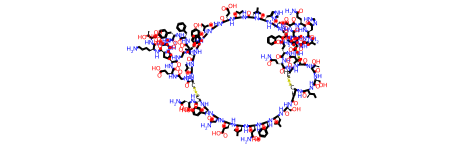

In [17]:
insulin = Chem.MolFromSmiles('CC[C@@H](C)[C@H]1C(=O)N[C@@H]2CSSC[C@@H](C(=O)N[C@@H](CSSC[C@@H](C(=O)NCC(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@@H](CSSC[C@H](NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@@H](NC2=O)CO)CC(C)C)CC3=CC=C(C=C3)O)CCC(=O)N)CC(C)C)CCC(=O)O)CC(=O)N)CC4=CC=C(C=C4)O)C(=O)N[C@@H](CC(=O)N)C(=O)O)C(=O)NCC(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](CCCNC(=N)N)C(=O)NCC(=O)N[C@@H](CC5=CC=CC=C5)C(=O)N[C@@H](CC6=CC=CC=C6)C(=O)N[C@@H](CC7=CC=C(C=C7)O)C(=O)N[C@@H]([C@H](C)O)C(=O)N8CCC[C@H]8C(=O)N[C@@H](CCCCN)C(=O)N[C@@H]([C@H](C)O)C(=O)O)C(C)C)CC(C)C)CC9=CC=C(C=C9)O)CC(C)C)C)CCC(=O)O)C(C)C)CC(C)C)CC2=CNC=N2)CO)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC2=CNC=N2)NC(=O)[C@H](CCC(=O)N)NC(=O)[C@H](C(=O)N)NC(=O)[C@H](C(C)C)NC(=O)[C@H](CC2=CC=CC=C2)N)C(=O)N[C@H](C(=O)N[C@H](C(=O)N1)CO)[C@H](C)O)NC(=O)[C@H](CCC(=O)N)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](C(C)C)NC(=O)[C@H]([C@H](C)CC)NC(=O)CN')
insulin

In [18]:
MW = Descriptors.MolWt(insulin)
HBA = Descriptors.NOCount(insulin)
HBD = Descriptors.NHOHCount(insulin)
LogP = Descriptors.MolLogP(insulin)

rules = [ MW <= 500, HBD <= 5, HBA <= 10, LogP <= 5 ]
print(rules)

[False, False, False, True]


Insulin would not be expected to be well absorbed orally. Because insulin is a large protein (51 amino acids), it:

Is too large to easily cross the intestinal membrane.
Has many hydrogen-bonding groups, making it highly polar.
Is degraded by digestive enzymes in the stomach and intestine before absorption.

Therefore, Lipinski's rules predict poor oral bioavailability.

This is why insulin is traditionally administered by injection rather than as a standard oral drug.